## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import missingno

import sys

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")


from utils import process_greek, create_grid, remove_accents

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
GREEK_TO_EN = str.maketrans({
    "Α": "A", "Β": "V", "Γ": "G", "Δ": "D", "Ε": "E", "Ζ": "Z", "Η": "I", "Θ": "TH",
    "Ι": "I", "Κ": "K", "Λ": "L", "Μ": "M", "Ν": "N", "Ξ": "X", "Ο": "O", "Π": "P",
    "Ρ": "R", "Σ": "S", "Τ": "T", "Υ": "Y", "Φ": "F", "Χ": "CH", "Ψ": "PS", "Ω": "O",
    "α": "a", "β": "v", "γ": "g", "δ": "d", "ε": "e", "ζ": "z", "η": "i", "θ": "th",
    "ι": "i", "κ": "k", "λ": "l", "μ": "m", "ν": "n", "ξ": "x", "ο": "o", "π": "p",
    "ρ": "r", "σ": "s", "ς": "s", "τ": "t", "υ": "y", "φ": "f", "χ": "ch",
    "ψ": "ps", "ω": "o"
})

def greek_to_english(df: pd.DataFrame, column: str) -> pd.DataFrame:
    df[column] = (
        df[column]
        .astype(str)
        .str.translate(GREEK_TO_EN)
    )
    return df

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'
NUTS2_ID = 'EL51'

In [5]:
greece_cm_gdf = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS2.shp",  encoding=enc)
greece_cm_gdf = greece_cm_gdf.loc[greece_cm_gdf['NUTS_ID'] == f'{NUTS2_ID}'].copy()

In [6]:
greece_cm_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
4,EL51,EL,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [7]:
greece_cm_gdf = greece_cm_gdf.to_crs(epsg=4326)
greece_cm_gdf.drop(columns=['NUTS_NAME'], inplace=True)
greece_cm_gdf.rename(columns={'NUTS_ID': 'div2_code',
                              'CNTR_CODE': 'div0_code',
                              'NAME_LATN': 'div2_name',
                              'CNTR_NAME': 'div0_name'}, inplace=True)

greece_cm_gdf['div0_name'] = 'ellada'
greece_cm_gdf['div1_code'] = 'EL5'
greece_cm_gdf['div1_name'] = 'voreia ellada'
greece_cm_gdf['div2_code'] = 'EL51'

greece_cm_gdf = greece_cm_gdf[['div0_code', 'div0_name',
                               'div1_code', 'div1_name',
                               'div2_code', 'div2_name',
                               'geometry']].copy()

In [8]:
greece_cm_gdf['div0_name'] = greece_cm_gdf['div0_name'].str.lower()
greece_cm_gdf['div1_name'] = greece_cm_gdf['div1_name'].str.lower()
greece_cm_gdf['div2_name'] = greece_cm_gdf['div2_name'].str.lower()

greece_cm_gdf['div0_name'] = greece_cm_gdf['div0_name'].apply(lambda x : remove_accents(x))
greece_cm_gdf['div1_name'] = greece_cm_gdf['div1_name'].apply(lambda x : remove_accents(x))
greece_cm_gdf['div2_name'] = greece_cm_gdf['div2_name'].apply(lambda x : remove_accents(x))

greece_cm_gdf.reset_index(drop=True, inplace=True)

In [9]:
greece_cm_gdf.head()

,div0_code,div0_name,div1_code,div1_name,div2_code,div2_name,geometry
0,EL,ellada,EL5,voreia ellada,EL51,"anatoliki makedonia, thraki","MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


<Axes: >

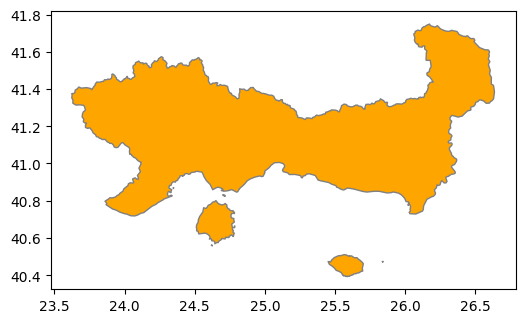

In [10]:
greece_cm_gdf.plot(facecolor="none", edgecolor='grey', figsize=(6,6), color='orange')

In [11]:
greece_cm_lv3 = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS3.shp",  encoding=enc)
greece_cm_lv3 = greece_cm_lv3[greece_cm_lv3['NUTS_ID'].str.startswith(NUTS2_ID, na=False)]
greece_cm_lv3.reset_index(drop=True, inplace=True) 

In [12]:
greece_cm_lv3.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,CNTR_NAME,geometry
0,EL511,EL,Evros,Έβρος,4.0,2,1,Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."
1,EL512,EL,Xanthi,Ξάνθη,2.0,2,1,Greece,"POLYGON ((25.17938 41.31019, 25.17954 41.30251..."
2,EL513,EL,Rodopi,Ροδόπη,2.0,3,1,Greece,"POLYGON ((25.90644 41.30757, 25.92568 41.27678..."
3,EL514,EL,Drama,Δράμα,2.0,2,2,Greece,"POLYGON ((24.78396 41.36019, 24.77851 41.35909..."
4,EL515,EL,"Thasos, Kavala","Θάσος, Καβάλα",3.0,3,1,Greece,"MULTIPOLYGON (((24.81349 40.85809, 24.80609 40..."


In [13]:
greece_cm_lv3 = greece_cm_lv3.to_crs(epsg=4326)
greece_cm_lv3.drop(columns=['CNTR_CODE', 'NUTS_NAME', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'CNTR_NAME'], inplace=True)

greece_cm_lv3.rename(columns={'NUTS_ID': 'div3_code',
                              'NAME_LATN': 'div3_name'}, inplace=True)

greece_cm_lv3['div3_name'] = greece_cm_lv3['div3_name'].str.lower()
greece_cm_lv3['div3_name'] = greece_cm_lv3['div3_name'].apply(lambda x : remove_accents(x))

greece_cm_lv3['div0_name'] = 'ellada'
greece_cm_lv3['div0_code'] = 'EL'
greece_cm_lv3['div1_name'] = 'voreia ellada'
greece_cm_lv3['div1_code'] = 'EL5'
greece_cm_lv3['div2_name'] = 'anatoliki makedonia thraki'
greece_cm_lv3['div2_code'] = 'EL51'

In [14]:
greece_cm_lv3 = greece_cm_lv3[['div0_code', 'div0_name',
                               'div1_code', 'div1_name',
                               'div2_code', 'div2_name',
                               'div3_code', 'div3_name',
                               'geometry']].copy()

In [15]:
greece_cm_lv3

,div0_code,div0_name,div1_code,div1_name,div2_code,div2_name,div3_code,div3_name,geometry
0,EL,ellada,EL5,voreia ellada,EL51,anatoliki makedonia thraki,EL511,evros,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."
1,EL,ellada,EL5,voreia ellada,EL51,anatoliki makedonia thraki,EL512,xanthi,"POLYGON ((25.17938 41.31019, 25.17954 41.30251..."
2,EL,ellada,EL5,voreia ellada,EL51,anatoliki makedonia thraki,EL513,rodopi,"POLYGON ((25.90644 41.30757, 25.92568 41.27678..."
3,EL,ellada,EL5,voreia ellada,EL51,anatoliki makedonia thraki,EL514,drama,"POLYGON ((24.78396 41.36019, 24.77851 41.35909..."
4,EL,ellada,EL5,voreia ellada,EL51,anatoliki makedonia thraki,EL515,"thasos, kavala","MULTIPOLYGON (((24.81349 40.85809, 24.80609 40..."


<Axes: >

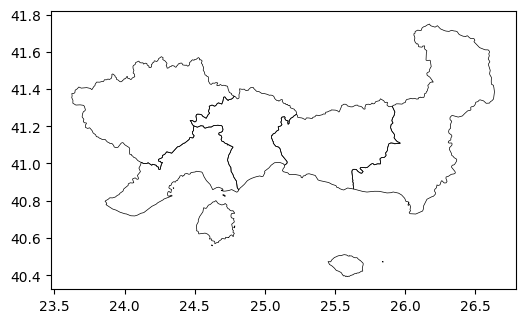

In [16]:
greece_cm_lv3.plot(facecolor="none", edgecolor='black', lw=0.5, figsize=(6,6), color='none')

In [17]:
greece_cm_lv4 = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\old\el_lau1.shp",  encoding=enc)
process_greek(greece_cm_lv4, 'NAME')
greece_cm_lv4_buffered = greece_cm_lv4.copy()
greece_cm_lv4_buffered = greece_cm_lv4_buffered.to_crs("EPSG:3035") 
greece_cm_lv4_buffered["geometry"] = greece_cm_lv4_buffered.geometry.buffer(-1000)

In [18]:
greece_cm_lv4_buffered = greece_cm_lv4_buffered[~greece_cm_lv4_buffered.is_empty & greece_cm_lv4_buffered.is_valid]
greece_cm_lv4.shape == greece_cm_lv4_buffered.shape

False

In [19]:
greece_cm_lv4_buffered = greece_cm_lv4_buffered.to_crs("EPSG:4326") 
cm = greece_cm_gdf.geometry.iloc[0]
greece_cm_lv4_buffered = greece_cm_lv4_buffered[greece_cm_lv4_buffered.covered_by(cm)]
greece_cm_lv4_buffered.reset_index(drop=True, inplace=True)

<Axes: >

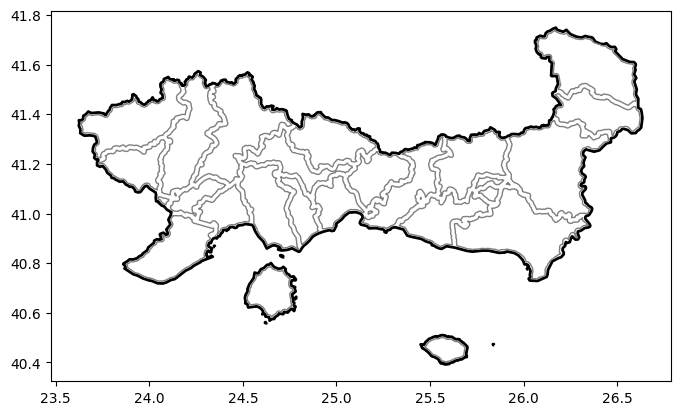

In [20]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=2)
greece_cm_lv4_buffered.plot(facecolor="none", edgecolor='grey', ax=ax, color='none')

In [21]:
kwd_ypes = greece_cm_lv4_buffered.KWD_YPES.to_list()

In [22]:
## This addition is due to missmatching geometries after buffering

## we are manually adding the missing KWD_YPES 9229 Dimos Elefsinas

# kwd_ypes.append('9229')

In [23]:
## Renaming div4_names names based on wrong shapefile names

## kalampakas -> metewrwn

# greece_cm_lv4.loc[greece_cm_lv4['NAME'] == 'καλαμπακας', 'NAME'] = 'μετεωρων'

In [24]:
greece_cm_lv4 = greece_cm_lv4[greece_cm_lv4['KWD_YPES'].isin(kwd_ypes)].copy()
greece_cm_lv4.rename(columns={'KWD_YPES': 'div4_code',
                             'NAME': 'div4_name'}, inplace=True)
greece_cm_lv4 = greek_to_english(greece_cm_lv4, "div4_name")
greece_cm_lv4.reset_index(drop=True, inplace=True)

In [25]:
greece_cm_lv4

,div4_name,div4_code,geometry
0,avdiron,9015,"MULTIPOLYGON (((25.11115 41.00509, 25.11129 41..."
1,alexandroypolis,9006,"MULTIPOLYGON (((26.02534 40.77036, 26.02556 40..."
2,arrianon,9019,"POLYGON ((25.84128 41.33854, 25.84157 41.33852..."
3,didymoteichoy,9007,"POLYGON ((26.33233 41.51492, 26.33276 41.51469..."
4,doxatoy,9001,"POLYGON ((24.33347 41.14739, 24.33534 41.14657..."
5,dramas,9002,"POLYGON ((24.26459 41.57286, 24.26479 41.57272..."
6,thasoy,9011,"MULTIPOLYGON (((24.70740 40.83051, 24.70756 40..."
7,iasmoy,9020,"POLYGON ((25.22333 41.26458, 25.22403 41.26445..."
8,kato neyrokopioy,9003,"POLYGON ((24.13763 41.53500, 24.13793 41.53496..."
9,kavalas,9012,"MULTIPOLYGON (((24.39181 40.91965, 24.39151 40..."


<Axes: >

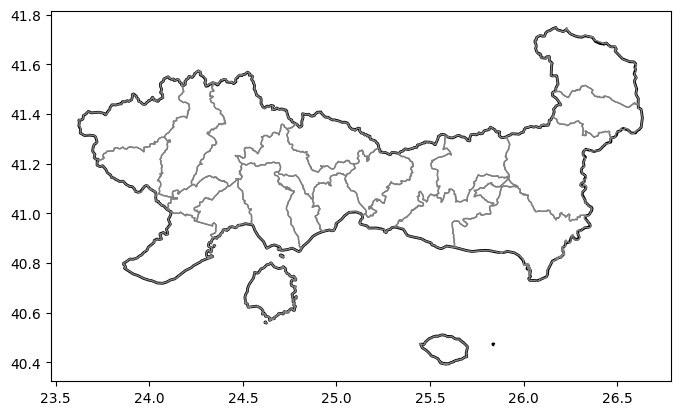

In [26]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=2)
greece_cm_lv4.plot(facecolor="none", edgecolor='grey', ax=ax, color='none')

In [27]:
## GPT Code to enrich lv4 with lv3 attributes

# -------------------------------------------------------------------
# Inputs (already in memory):
#   greece_cm_lv3: polygons with div0..div3 + geometry
#   greece_cm_lv4: polygons with div4 + geometry
# Output:
#   greece_cm_lv4_enriched: lv4 with div0..div3 columns added
# -------------------------------------------------------------------

ADMIN_COLS = [
    "div0_code", "div0_name",
    "div1_code", "div1_name",
    "div2_code", "div2_name",
    "div3_code", "div3_name",
]

# 1) Ensure CRS is set and aligned
if greece_cm_lv3.crs is None or greece_cm_lv4.crs is None:
    raise ValueError(
        "One of the GeoDataFrames has no CRS set. "
        "Set it first with .set_crs(..., inplace=True) before running this."
    )

if greece_cm_lv3.crs != greece_cm_lv4.crs:
    greece_cm_lv4 = greece_cm_lv4.to_crs(greece_cm_lv3.crs)

# 2) Compute inside-points for lv4 (use representative_point to guarantee inside)
lv4 = greece_cm_lv4.copy()
crs_orig = lv4.crs

# For accurate point computations, do it in a metric CRS if current CRS is geographic
if crs_orig.is_geographic:
    # ETRS89 / LAEA Europe (meters) - safe default for Europe/Greece
    lv4_metric = lv4.to_crs(3035)
    lv4_metric["__pt"] = lv4_metric.geometry.representative_point()
    lv4["__pt"] = lv4_metric["__pt"].to_crs(crs_orig)
else:
    lv4["__pt"] = lv4.geometry.representative_point()

lv4_pts = gpd.GeoDataFrame(
    lv4[["div4_code", "div4_name", "__pt"]].copy(),
    geometry="__pt",
    crs=crs_orig,
)

# 3) Spatial join: which lv3 polygon contains the lv4 inside-point?
lv3_for_join = greece_cm_lv3[ADMIN_COLS + ["geometry"]].copy()

# If you suspect invalid geometries in lv3, uncomment:
# lv3_for_join["geometry"] = lv3_for_join.geometry.make_valid()

joined = (
    gpd.sjoin(
        lv4_pts,
        lv3_for_join,
        how="left",
        predicate="within",   # point within polygon
    )
    .drop(columns=["index_right"], errors="ignore")
)

# 4) Merge attributes back onto lv4 polygons
greece_cm_lv4_enriched = (
    greece_cm_lv4
    .merge(joined[["div4_code"] + ADMIN_COLS], on="div4_code", how="left")
)

# 5) Quick diagnostics
missing = greece_cm_lv4_enriched[ADMIN_COLS].isna().any(axis=1)
print(f"Unmatched LV4 rows (no containing LV3 polygon found): {missing.sum()} / {len(missing)}")


Unmatched LV4 rows (no containing LV3 polygon found): 0 / 22


In [28]:
greece_cm_lv4 = greece_cm_lv4_enriched[['div0_name', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'geometry']].copy()

In [29]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

In [30]:
df_grid_cm_d2 = create_grid(empty_gdf, greece_cm_gdf, col_municipal='div0_name', dimension=2)

In [31]:
df_grid_cm_d2.head()

,geometry,centers,div0_name,x,y,resolution_km
0,"POLYGON ((23.67061 41.32644, 23.67061 41.34440...",POINT (23.658819828962606 41.33541930901127),ellada,23.65882,41.33542,2
1,"POLYGON ((23.67061 41.34440, 23.67061 41.36237...",POINT (23.658819828962606 41.35338600061149),ellada,23.65882,41.35339,2
2,"POLYGON ((23.67061 41.36237, 23.67061 41.38034...",POINT (23.658819828962606 41.3713526922117),ellada,23.65882,41.37135,2
3,"POLYGON ((23.69420 41.32644, 23.69420 41.34440...",POINT (23.682409714937673 41.33541930901127),ellada,23.68241,41.33542,2
4,"POLYGON ((23.69420 41.34440, 23.69420 41.36237...",POINT (23.682409714937673 41.35338600061149),ellada,23.68241,41.35339,2


In [32]:
df_grid_cm_d2.shape

(3266, 6)

<Axes: >

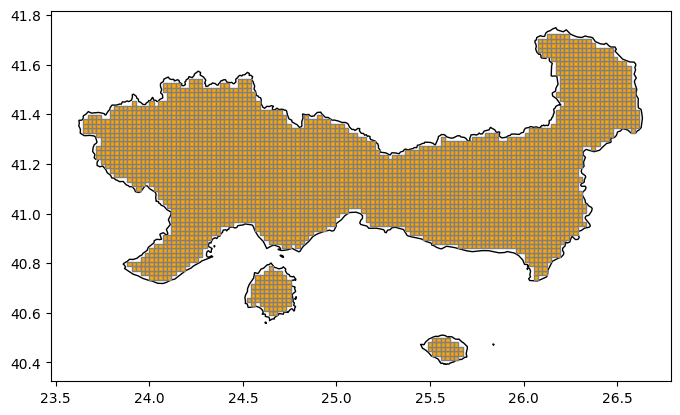

In [33]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
df_grid_cm_d2.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [34]:
df_grid_cm_d2.set_geometry('centers', inplace=True)
df_grid_cm_d2.set_crs(epsg=4326, inplace=True)

,geometry,centers,div0_name,x,y,resolution_km
0,"POLYGON ((23.67061 41.32644, 23.67061 41.34440...",POINT (23.65882 41.33542),ellada,23.65882,41.33542,2
1,"POLYGON ((23.67061 41.34440, 23.67061 41.36237...",POINT (23.65882 41.35339),ellada,23.65882,41.35339,2
2,"POLYGON ((23.67061 41.36237, 23.67061 41.38034...",POINT (23.65882 41.37135),ellada,23.65882,41.37135,2
3,"POLYGON ((23.69420 41.32644, 23.69420 41.34440...",POINT (23.68241 41.33542),ellada,23.68241,41.33542,2
4,"POLYGON ((23.69420 41.34440, 23.69420 41.36237...",POINT (23.68241 41.35339),ellada,23.68241,41.35339,2
...,...,...,...,...,...,...
3261,"POLYGON ((26.59576 41.48814, 26.59576 41.50610...",POINT (26.58397 41.49712),ellada,26.58397,41.49712,2
3262,"POLYGON ((26.61935 41.34440, 26.61935 41.36237...",POINT (26.60756 41.35339),ellada,26.60756,41.35339,2
3263,"POLYGON ((26.61935 41.36237, 26.61935 41.38034...",POINT (26.60756 41.37135),ellada,26.60756,41.37135,2
3264,"POLYGON ((26.61935 41.38034, 26.61935 41.39830...",POINT (26.60756 41.38932),ellada,26.60756,41.38932,2


In [35]:
greece_cm_grid = gpd.sjoin(df_grid_cm_d2, greece_cm_lv4, how='left', op='within')

In [36]:
greece_cm_grid.head()

,geometry,centers,div0_name_left,x,y,resolution_km,index_right,div0_name_right,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code
0,"POLYGON ((23.67061 41.32644, 23.67061 41.34440...",POINT (23.65882 41.33542),ellada,23.65882,41.33542,2,8,ellada,voreia ellada,anatoliki makedonia thraki,drama,kato neyrokopioy,EL,EL5,EL51,EL514,9003
1,"POLYGON ((23.67061 41.34440, 23.67061 41.36237...",POINT (23.65882 41.35339),ellada,23.65882,41.35339,2,8,ellada,voreia ellada,anatoliki makedonia thraki,drama,kato neyrokopioy,EL,EL5,EL51,EL514,9003
2,"POLYGON ((23.67061 41.36237, 23.67061 41.38034...",POINT (23.65882 41.37135),ellada,23.65882,41.37135,2,8,ellada,voreia ellada,anatoliki makedonia thraki,drama,kato neyrokopioy,EL,EL5,EL51,EL514,9003
3,"POLYGON ((23.69420 41.32644, 23.69420 41.34440...",POINT (23.68241 41.33542),ellada,23.68241,41.33542,2,8,ellada,voreia ellada,anatoliki makedonia thraki,drama,kato neyrokopioy,EL,EL5,EL51,EL514,9003
4,"POLYGON ((23.69420 41.34440, 23.69420 41.36237...",POINT (23.68241 41.35339),ellada,23.68241,41.35339,2,8,ellada,voreia ellada,anatoliki makedonia thraki,drama,kato neyrokopioy,EL,EL5,EL51,EL514,9003


In [37]:
greece_cm_grid.dropna(inplace=True)

In [38]:
final_grid = greece_cm_grid[['x', 'y', 'div0_name_right', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']].copy()
final_grid.set_geometry('geometry', inplace=True)
final_grid.rename(columns={'div0_name_right': "div0_name"}, inplace=True)
final_grid.sort_values(by=['x', 'y', 'div4_name'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)

<Axes: >

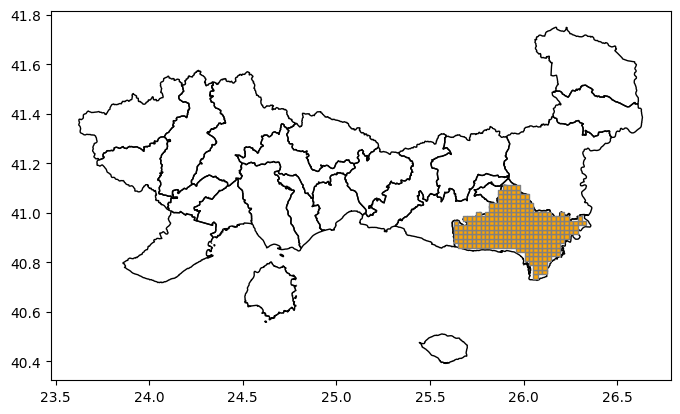

In [39]:
ax = greece_cm_lv4.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
final_grid[final_grid['div4_name'] == 'alexandroypolis'].plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [40]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of greece_cm_lv4: {greece_cm_lv4.div4_name.unique().shape}')

Shape of final_grid: (22,)
Shape of greece_cm_lv4: (22,)


In [41]:
diff = list(set(greece_cm_lv4.div4_name.unique().tolist()) - set(final_grid.div4_name.unique().tolist()))
print(f'Difference is: {len(diff)}')
print(f'Missing GIDs are: {diff}') 

Difference is: 0
Missing GIDs are: []


In [42]:
missing_LAUs_d2 = greece_cm_lv4[greece_cm_lv4.div4_name.isin(diff)].copy()
missing_LAUs_d2.reset_index(drop=True, inplace=True)

In [43]:
missing_LAUs_d2

,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,geometry


In [44]:
missing_LAUs_d2["centers"] = missing_LAUs_d2.geometry.centroid

In [45]:
missing_LAUs_d2['resolution_km'] = 1

In [46]:
# ax = missing_LAUs_d2.plot(edgecolor='black', facecolor='none', figsize=(6, 6))
# missing_LAUs_d2['centers'].plot(ax=ax, color='red', markersize=5)

In [47]:
missing_LAUs_d2["x"] = missing_LAUs_d2["centers"].x
missing_LAUs_d2["y"] = missing_LAUs_d2["centers"].y
missing_LAUs_d2 = missing_LAUs_d2[['x', 'y', 'div0_name', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']]



In [48]:
missing_LAUs_d2.head()

,x,y,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,centers,geometry


In [49]:
final_grid = pd.concat([final_grid, missing_LAUs_d2], ignore_index=True)

In [50]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of greece_cm_lv4: {greece_cm_lv4.div4_name.unique().shape}')

Shape of final_grid: (22,)
Shape of greece_cm_lv4: (22,)


In [51]:
final_grid.sort_values(by=['div2_code', 'div3_code', 'div4_code', 'x', 'y'], inplace = True)
final_grid.rename(columns={'x': 'longitude', 'y': 'latitude'}, inplace=True)
final_grid.reset_index(drop=True, inplace=True)
final_grid.drop(columns=['centers'], inplace=True)
final_grid

,longitude,latitude,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,geometry
0,25.64037,40.88625,ellada,voreia ellada,anatoliki makedonia thraki,evros,alexandroypolis,EL,EL5,EL51,EL511,9006,2,"POLYGON ((25.65217 40.87727, 25.65217 40.89524..."
1,25.64037,40.90422,ellada,voreia ellada,anatoliki makedonia thraki,evros,alexandroypolis,EL,EL5,EL51,EL511,9006,2,"POLYGON ((25.65217 40.89524, 25.65217 40.91320..."
2,25.64037,40.92219,ellada,voreia ellada,anatoliki makedonia thraki,evros,alexandroypolis,EL,EL5,EL51,EL511,9006,2,"POLYGON ((25.65217 40.91320, 25.65217 40.93117..."
3,25.64037,40.94015,ellada,voreia ellada,anatoliki makedonia thraki,evros,alexandroypolis,EL,EL5,EL51,EL511,9006,2,"POLYGON ((25.65217 40.93117, 25.65217 40.94914..."
4,25.64037,40.95812,ellada,voreia ellada,anatoliki makedonia thraki,evros,alexandroypolis,EL,EL5,EL51,EL511,9006,2,"POLYGON ((25.65217 40.94914, 25.65217 40.96710..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3261,24.31934,40.92219,ellada,voreia ellada,anatoliki makedonia thraki,"thasos, kavala",paggaioy,EL,EL5,EL51,EL515,9014,2,"POLYGON ((24.33113 40.91320, 24.33113 40.93117..."
3262,24.31934,40.94015,ellada,voreia ellada,anatoliki makedonia thraki,"thasos, kavala",paggaioy,EL,EL5,EL51,EL515,9014,2,"POLYGON ((24.33113 40.93117, 24.33113 40.94914..."
3263,24.34293,40.92219,ellada,voreia ellada,anatoliki makedonia thraki,"thasos, kavala",paggaioy,EL,EL5,EL51,EL515,9014,2,"POLYGON ((24.35472 40.91320, 24.35472 40.93117..."
3264,24.34293,40.94015,ellada,voreia ellada,anatoliki makedonia thraki,"thasos, kavala",paggaioy,EL,EL5,EL51,EL515,9014,2,"POLYGON ((24.35472 40.93117, 24.35472 40.94914..."


In [52]:
string_cols = final_grid.select_dtypes(include=['object', 'string']).columns

final_grid[string_cols] = final_grid[string_cols].apply(lambda col: col.map(remove_accents))
final_grid[string_cols] = final_grid[string_cols].apply(lambda col: col.str.replace(r"[,.]", "", regex=True))

In [53]:
if final_grid['div3_code'].isnull().any():
    raise ValueError("div3_code contains NULL values, need rules to handle them.")

# Create a "counter" per div3_code
final_grid['counter'] = final_grid.groupby('div3_code').cumcount() + 1

# Convert counter to hex, padded to 5 digits
final_grid['hex_counter'] = final_grid['counter'].apply(lambda x: format(x, '05X'))

# Final point_code = div3_code + hex_counter
final_grid['point_code'] = final_grid['div3_code'] + final_grid['hex_counter']

# Drop helper columns
final_grid = final_grid.drop(columns=['counter', 'hex_counter'])

In [54]:
final_grid = final_grid[['point_code', 'latitude', 'longitude', 'div0_name', 'div0_code', 'div1_name', 'div1_code', 'div2_name', 'div2_code', 'div3_name', 'div3_code', 'div4_name','div4_code', 'resolution_km', 'geometry']].copy()

<Axes: >

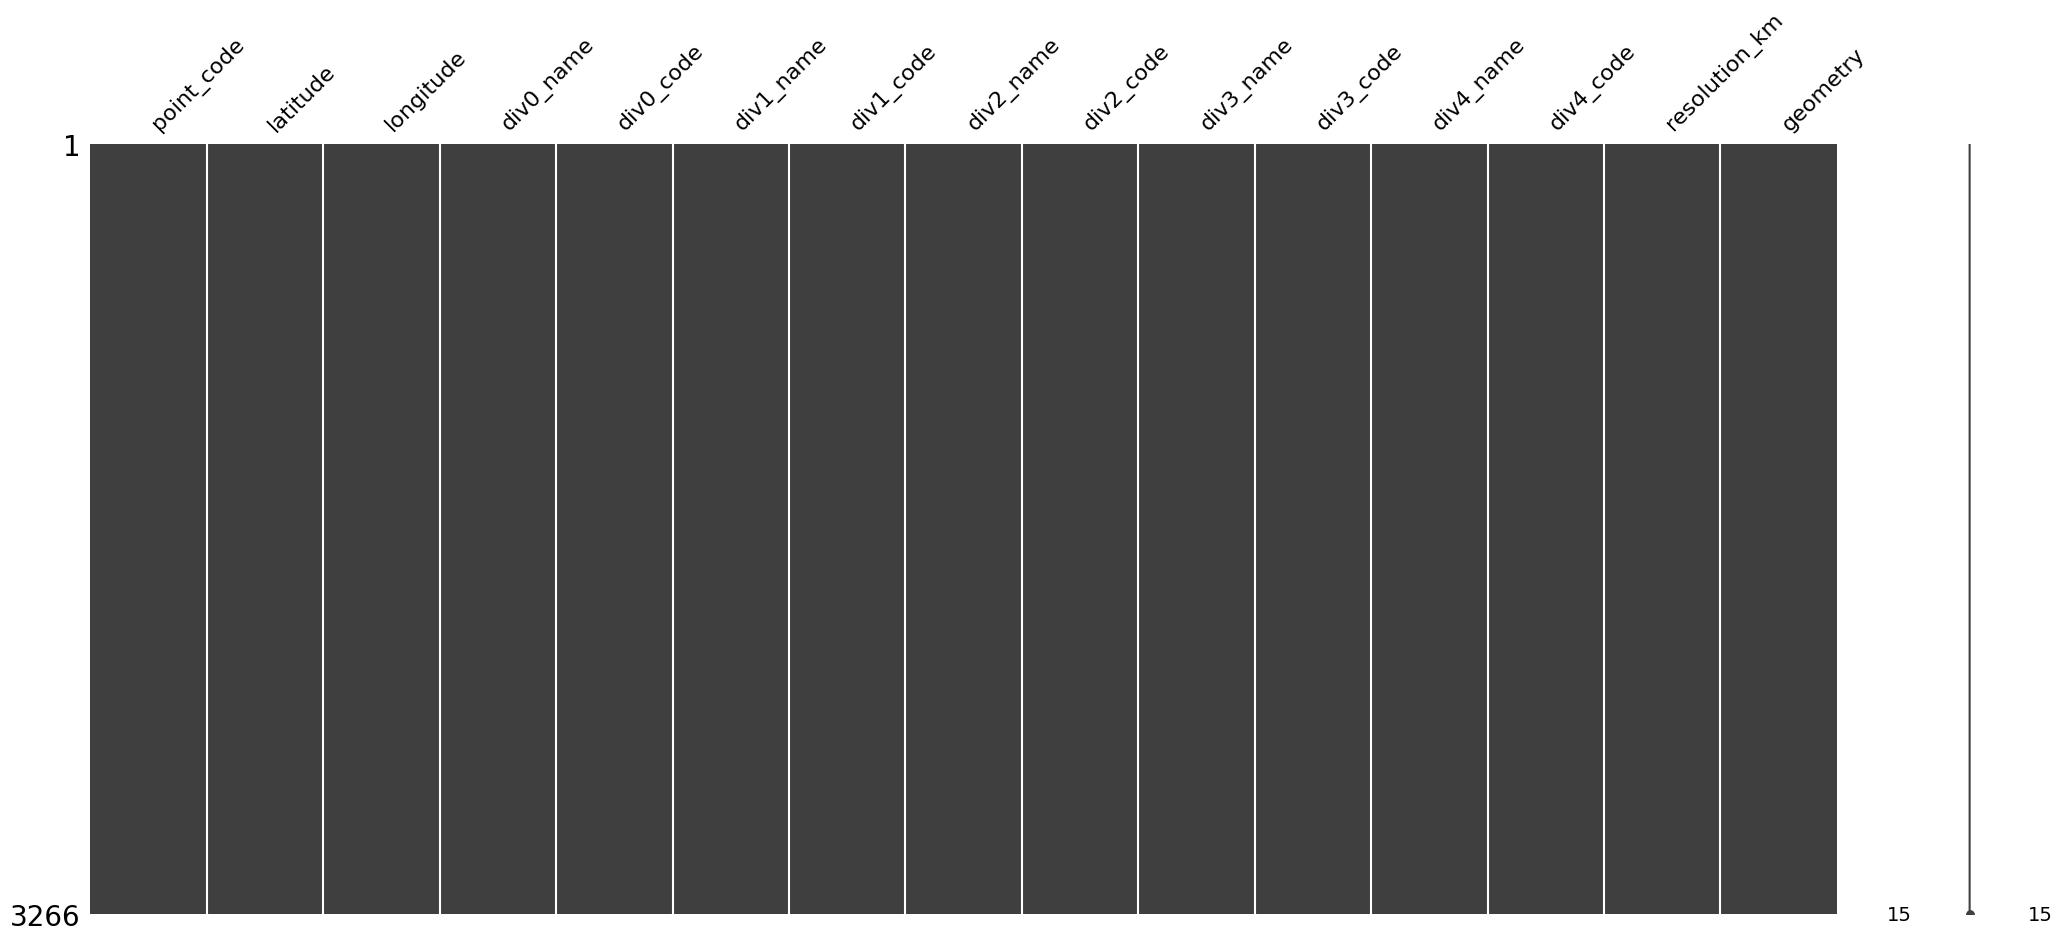

In [55]:
missingno.matrix(final_grid)

In [56]:
final_grid

,point_code,latitude,longitude,div0_name,div0_code,div1_name,div1_code,div2_name,div2_code,div3_name,div3_code,div4_name,div4_code,resolution_km,geometry
0,EL51100001,40.88625,25.64037,ellada,EL,voreia ellada,EL5,anatoliki makedonia thraki,EL51,evros,EL511,alexandroypolis,9006,2,"POLYGON ((25.65217 40.87727, 25.65217 40.89524..."
1,EL51100002,40.90422,25.64037,ellada,EL,voreia ellada,EL5,anatoliki makedonia thraki,EL51,evros,EL511,alexandroypolis,9006,2,"POLYGON ((25.65217 40.89524, 25.65217 40.91320..."
2,EL51100003,40.92219,25.64037,ellada,EL,voreia ellada,EL5,anatoliki makedonia thraki,EL51,evros,EL511,alexandroypolis,9006,2,"POLYGON ((25.65217 40.91320, 25.65217 40.93117..."
3,EL51100004,40.94015,25.64037,ellada,EL,voreia ellada,EL5,anatoliki makedonia thraki,EL51,evros,EL511,alexandroypolis,9006,2,"POLYGON ((25.65217 40.93117, 25.65217 40.94914..."
4,EL51100005,40.95812,25.64037,ellada,EL,voreia ellada,EL5,anatoliki makedonia thraki,EL51,evros,EL511,alexandroypolis,9006,2,"POLYGON ((25.65217 40.94914, 25.65217 40.96710..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3261,EL515001CA,40.92219,24.31934,ellada,EL,voreia ellada,EL5,anatoliki makedonia thraki,EL51,thasos kavala,EL515,paggaioy,9014,2,"POLYGON ((24.33113 40.91320, 24.33113 40.93117..."
3262,EL515001CB,40.94015,24.31934,ellada,EL,voreia ellada,EL5,anatoliki makedonia thraki,EL51,thasos kavala,EL515,paggaioy,9014,2,"POLYGON ((24.33113 40.93117, 24.33113 40.94914..."
3263,EL515001CC,40.92219,24.34293,ellada,EL,voreia ellada,EL5,anatoliki makedonia thraki,EL51,thasos kavala,EL515,paggaioy,9014,2,"POLYGON ((24.35472 40.91320, 24.35472 40.93117..."
3264,EL515001CD,40.94015,24.34293,ellada,EL,voreia ellada,EL5,anatoliki makedonia thraki,EL51,thasos kavala,EL515,paggaioy,9014,2,"POLYGON ((24.35472 40.93117, 24.35472 40.94914..."


In [57]:
final_grid.drop(columns='geometry').to_csv(f'../../data/{NUTS2}/GR_{NUTS2}_Grid_DB.csv', encoding=enc, index = False)
# final_grid.to_file(f'../data/CM_Nord_Grid.shp', encoding = 'utf-8')